# Elastic Net

In [54]:
# import potrebnych kniznic a konfiguracia notebooku

import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

import shap

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import functions
importlib.reload(functions)

import functions_elastic_net
importlib.reload(functions_elastic_net)
from functions_elastic_net import rolling_forecast_elastic_net, evaluate_forecast

import cred
importlib.reload(cred)
from cred import DATA_PATH_CRED

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")

Importy uspesne.


In [55]:
# konfiguracia a stiahnutie dat
main_dir = Path(DATA_PATH_CRED)
data_mod = "data_mod.csv"
pp_orig = "data.xlsx"
DATA_PATH_DATA_MOD  = main_dir / data_mod
DATA_PATH_DATA = main_dir / pp_orig
SHEET_NAME_PP = "pp"
SHEET_NAME_EXOG = "exog"
TEST_SIZE = 24
RANDOM_STATE = 24
TARGET_VAR = "pp_sa_ca_jd"

df_raw = pd.read_csv(DATA_PATH_DATA_MOD)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

df_pp = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_PP)
df_pp = df_pp.set_index("datum").sort_index()
df_pp = df_pp.asfreq("MS")

df_exog = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_EXOG)
df_exog = df_exog.set_index("datum").sort_index()
df_exog = df_exog.asfreq("MS")
df_exog = df_exog.drop(columns=["datum"], errors="ignore")

In [41]:
CV_SPLITS = 5
REFIT_EVERY = 1

df_fin = df.drop(columns = ["pp_nonsa", "pp_sa_orig"])
exog_cols = df_fin.drop(columns = [TARGET_VAR]).columns.to_list()

results, models, coef_history = rolling_elastic_net( 
    df_final= df_fin, 
    y_col=TARGET_VAR,
    exog_cols=exog_cols,
    test_size=TEST_SIZE,
    cv_splits=CV_SPLITS,
    refit_every=REFIT_EVERY,
    verbose=True
)


  [2024-01-01] refit: alpha=0.1274, l1_ratio=0.95
  [2024-02-01] refit: alpha=0.1274, l1_ratio=0.90
  [2024-03-01] refit: alpha=0.1274, l1_ratio=0.95
  [2024-04-01] refit: alpha=0.1274, l1_ratio=0.50
  [2024-05-01] refit: alpha=0.1274, l1_ratio=0.50
  [2024-06-01] refit: alpha=0.1274, l1_ratio=0.50
  [2024-07-01] refit: alpha=0.1274, l1_ratio=0.50
  [2024-08-01] refit: alpha=0.0785, l1_ratio=0.70
  [2024-09-01] refit: alpha=0.0785, l1_ratio=0.50
  [2024-10-01] refit: alpha=0.0785, l1_ratio=0.70
  [2024-11-01] refit: alpha=0.0785, l1_ratio=0.70
  [2024-12-01] refit: alpha=0.0785, l1_ratio=0.70
  [2025-01-01] refit: alpha=0.0785, l1_ratio=0.90
  [2025-02-01] refit: alpha=0.0785, l1_ratio=0.70
  [2025-03-01] refit: alpha=0.0785, l1_ratio=0.70
  [2025-04-01] refit: alpha=0.0785, l1_ratio=0.70
  [2025-05-01] refit: alpha=0.0785, l1_ratio=0.90
  [2025-06-01] refit: alpha=0.0785, l1_ratio=0.90
  [2025-07-01] refit: alpha=0.0785, l1_ratio=0.90
  [2025-08-01] refit: alpha=0.0785, l1_ratio=0.50


In [64]:
X = df.drop(columns = ["pp_nonsa", "pp_sa_orig"])
y = df[TARGET_VAR]
init_train_size = len(y) - TEST_SIZE
last_train_value = float(df_pp[TARGET_VAR].iloc[init_train_size - 1])
last_train_value

100.67146462451447

In [65]:
results_elnet, models_elnet, coef_hist = rolling_forecast_elastic_net(
    X=X,
    y_diff=y,
    level_series=df_pp[TARGET_VAR],
    initial_train_size= init_train_size,
    last_train_value=last_train_value,
    refit_every=1,
    reconstruction="onestep"
)

RMSE (diferencia): 0.2960
RMSE (level, onestep rekonstrukcia): 0.2960
MAPE (level, WMAPE = sum|chyba| / sum|skutocnost|): 0.22%
ME (level): -0.0082


In [67]:
metrics = evaluate_forecast(results_elnet)
print(metrics.to_string(index=False))


 0.295977
 0.295977
 0.215561
 0.210837
-0.008242


In [69]:
selected_counts = coef_history.groupby("forecast_date")["n_selected"].first()
print(selected_counts.describe())

count    24.000000
mean     14.791667
std       2.206299
min      11.000000
25%      13.000000
50%      15.000000
75%      16.000000
max      20.000000
Name: n_selected, dtype: float64


In [70]:
top_feat = coef_history[coef_history["selected"]].groupby("feature")["abs_coef"].mean().sort_values(ascending = False)
top_feat


feature
trzby_priemysel_sa              1.375672
crisis_dummy                    1.112298
export_celkovy_sa               1.064556
unem_prod                       0.196755
uvery_celkom                    0.155416
expected_employment             0.146595
hdd                             0.139837
cdd                             0.126647
sh_prices_non_sa                0.110207
kurz_usd_eur                    0.090945
economic_sentiment              0.069880
cpi_nsa                         0.060292
vklady_nefinancne_podniky       0.054679
sadzba_3m_euribor               0.034134
inflation                       0.025310
expected_industry_production    0.023738
expected_product_prices         0.014010
oil_price_eur                   0.012277
oil_europe_usd                  0.008992
foreign_demand_sa               0.008678
ipcv_priemysel                  0.002076
Name: abs_coef, dtype: float64

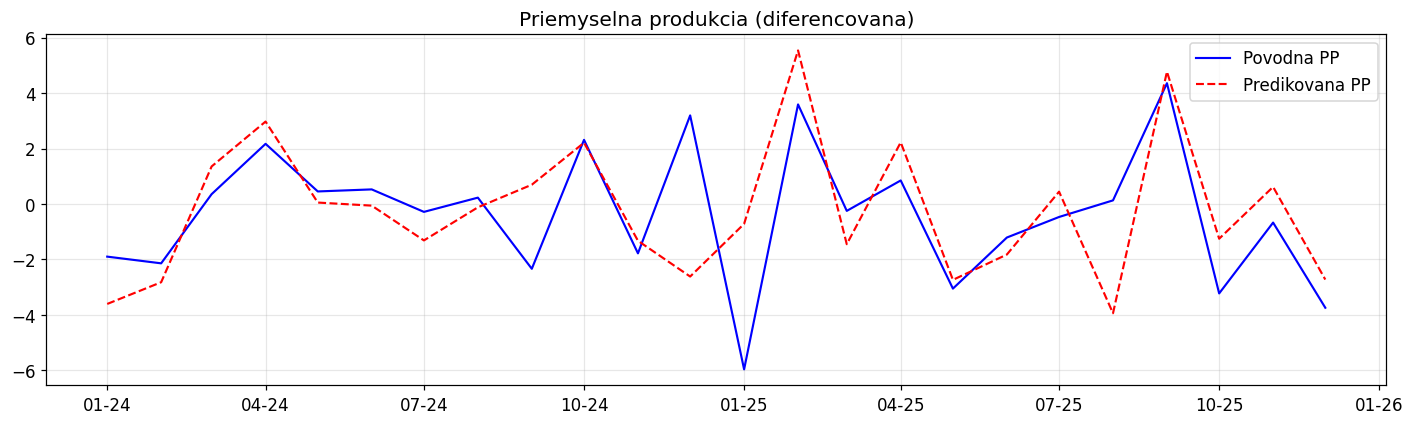

In [71]:
fig, ax = plt.subplots()
ax.plot(results.index, results["actual_diff"], color= "blue", linewidth = 1.4, label = "Povodna PP")
ax.plot(results.index, results["predicted_diff"], color= "red", linestyle='--', linewidth = 1.4, label = "Predikovana PP")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
ax.set_title("Priemyselna produkcia (diferencovana)")
ax.legend()
plt.tight_layout()
plt.show()

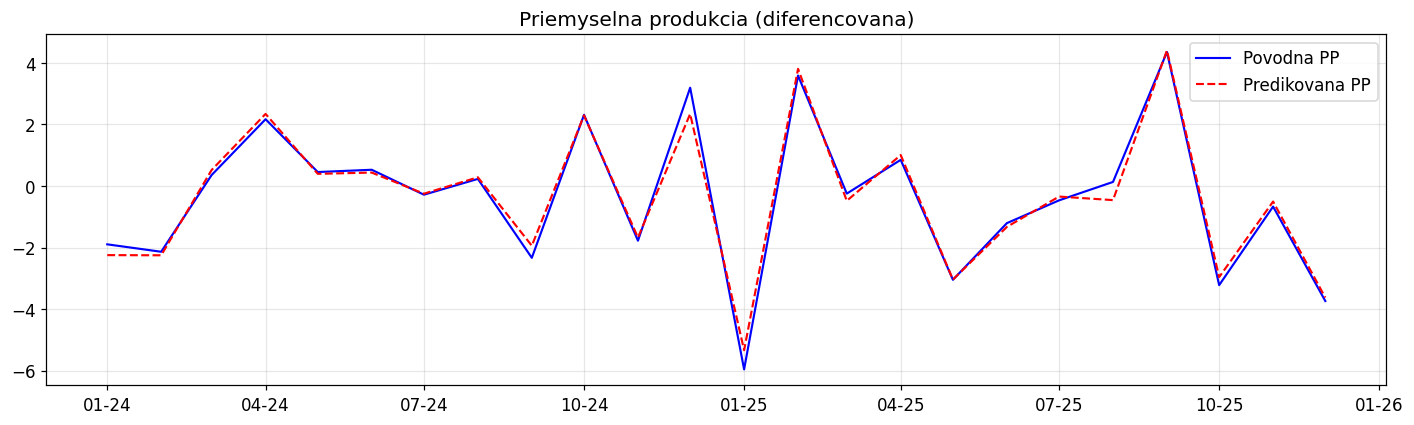

In [72]:
fig, ax = plt.subplots()
ax.plot(results_elnet.index, results_elnet["actual_diff"], color= "blue", linewidth = 1.4, label = "Povodna PP")
ax.plot(results_elnet.index, results_elnet["predicted_diff"], color= "red", linestyle='--', linewidth = 1.4, label = "Predikovana PP")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%y"))
ax.set_title("Priemyselna produkcia (diferencovana)")
ax.legend()
plt.tight_layout()
plt.show()